# Class 2: Other useful functions and intro to numpy

# Plan:

<h2>

1) Useful vanilla python functions and some array properties

2) Numpy arrays

3) Useful numpy functions
</h2>

# Imports

In [ ]:
#upgrade pip in case you got an old version
!python -m pip install --upgrade pip
#install numpy library quietly
!pip install numpy --user -q 

import warnings 
warnings.filterwarnings('ignore') #disable warnings cause you're a pro and symbols on the screen can't tell you how to write code
 
import numpy as np 

# Class material

## Useful vanilla python functions and some array properties

In [ ]:
!echo "Hey there" > readme.txt


file = open("readme.txt", "r")
print(file.close())

Now that you're familiar with the basics, time for some more advanced stuff:


```range``` is an important function. It creates a generator of values for iteration that can also be converted.\
The syntax is ```range(start, end, step)```:

In [ ]:
#prints values from 10 to 17 (excluding 17) with the step of 3
for i in range(10, 17, 3):
    print(i)

```open``` lets you read, write and refactor files with python. Here's the basic syntax:\
(For this example assume we have a file locally named "readme.txt")

In [ ]:
#note that you need to specify local or global path to the file
file = open("./readme.txt", "r") #open the file in the read mode, "w" to overwrite/create a file, "a" to append to the file
file_contents = file.read() #read the file as one string. Do .readlines() to get a list of lines
file.close() #close the file. You should ALWAYS close the file

```with as``` lets you take an operator and rename it, it also functions as an exceptionhandler for some functions, like ```open```. Here's the syntax:


In [ ]:
with open("./readme.txt", "r") as file:
    file_contents = file.readlines() #if there'll be an error here, the file will still be closed because we used 'with' (it doesn't apply to everything)

Next one up is ```zip```, which helps iterate through several arrays at once, you just list them among the function arguments ```zip(arr_1, arr_2, arr_3)```.\
For example if we want to iterate through 3 arrays:

In [ ]:
#quickly define 3 arrays and show them
arr_1, arr_2, arr_3 = list(range(5)), list(range(1,6)), list(range(10, 20, 2))
print(arr_1, arr_2, arr_3)

#this loop will iterate through the 3 arrays simultaneously with item_1, item_2, item_3 being the iterable items of the arrays respectively
for item_1, item_2, item_3 in zip(arr_1, arr_2, arr_3):
    print(item_1, item_2, item_3)

You can also ```enumerate``` and ```zip``` in conjuction:

In [ ]:
#quickly define 3 arrays and show them
arr_1, arr_2, arr_3 = list(range(5)), list(range(1,6)), list(range(10, 20, 2))
print(arr_1, arr_2, arr_3)

#this loop will iterate through the 3 arrays simultaneously with item_1, item_2, item_3 being the iterable items of the arrays respectively
for idx, (item_1, item_2, item_3) in enumerate(zip(arr_1, arr_2, arr_3)):
    print(idx, item_1, item_2, item_3)

The ```assert``` function helps verify some condition when defining a function.\
The syntax would be ```assert some_logical_expression, string_to_print_when_expression_is_false```\
Example:


In [ ]:
#This function will throw an error if a or b is a negative value 
def positive_integer_addition(a:int, b:int)->int:
    assert (a > 0) and (b > 0), "Either a or b is negative"
    return a + b

It is also very useful to understand how to integrate the variables (or code) in you string variables (when you need to print some variable's value for example).\
There are 4 types of strings: generic, raw, format, raw+format:\
Generic string simply houses the characters inside it and executes the escape characters (```\n``` is the escape charater for a new line): 

In [ ]:
'''
This will print:
This is a generic string
It executes the escape characters
'''
print("This is a generic string \nIt executes the escape characters")

Raw string doesn't execute escape characters, it is just raw characters, you indicate the raw string by ```r``` in front:


In [ ]:
'''
This will print:
This string is raw \n It doesn't execute escape characters
'''
print(r"This string is raw \n It doesn't execute escape characters")

Format string executes escape characters and it allows for code entries, you indicate it by ```f``` in front, the code is executed inside the curly braces:

In [ ]:
'''
This will print:
This is a format string 
1+2=3
'''
print(f"This is a format string\n1+2={1+2}")

Raw + format string combines the properties of both:

In [ ]:
'''
This will print:
This is a format string\n1+2=3
'''
print(fr"This is a format string\n1+2={1+2}")

Time to check out some cool array properties of python lists. Let's firstly explore slicing:\
Just as you can define a list of values via the ```range``` function, you can slice python lists with the similar syntax.\
Suppose you want to get values from list in some index range with some step, then you use slicing with the syntax ```arr[start:end:step]```

In [ ]:
#define some array
arr = list(range(10))

#This will get you the first 5 elements
print(arr[:5])

#This will get you all the elements with index 3 or larger in the array
print(arr[3:])

#This will get you all the elements with index values ranging from 4 to 9 (exclusive)
print(arr[4:9])

#This will get you all the elements with index values from 2 to 6 (exclusive) with step 2
print(arr[2:6:2])

#This will get you the last element of the list
print(arr[-1])

#This will get you the last 5 elements of the array
print(arr[-5:])

1. Create a text file "data.txt" with 3 lines of text. Write a program that opens the file using open() in read mode, reads the entire content, prints it, and properly closes the file

In [ ]:
#File creation
file = open("data.txt", "w") #create file
file.write("Hello\nWorld\nI write code!\n") #write 3 lines of text
file.close() #close the file after creation

#actual task
file_read = open("data.txt", "r")
content = file_read.read() #read the entire file
print(content) #print its contents
file_read.close() #close the file

2. Rewrite the previous exercise using with as syntax. Read the file line by line using readlines() and print each line with its line number

In [ ]:
with open("data.txt", "r") as file_read:
    content = file_read.readlines() #read the entire file
    for id_line, line in enumerate(content): #iterate over the lines
        print(f'line number {id_line} that contains {line}') #print line's index and contents
    #we don't need file_read.close() here as we use the with keyword

3. Write a function read_config(filename) that uses assert to verify the file exists (try to open it) and has a .txt extension before reading.\
Print the contents of the file after reading it.\
If the file doesn't exist: create it and write "empty config" into it

In [ ]:
def read_config(filename:str)->None:
    assert filename.split('.')[-1] == "txt", "The file doesn't have a .txt extension"
    file = None
    try:
        file = open(filename, "r")
    except:
        with open(filename, "w") as file:
            file.write("empty config")
    else:
        with open(filename, "r") as file:
            print(file.read())
    finally:
        return None

read_config("tstsdg.txt")

4. Write a function ```event_logger```, which takes no arguments. It should read events from the user and log them into the file numbering each event.\
For example if the user enters ```Breakfast``` and then enters ```Sleep``` then the file should contain the information in the form:
```
1. Breakfast
2. Sleep
```

In [ ]:
def event_logger():
    idx, user_input = 1, ''
    try:
        with open("user_log.txt", "r") as file_read:
            contents = file_read.readlines() #get lines as python list
            # idx = len(contents) + 1 #also achieves the same thing!
            idx = int(contents[-1].split('.')[0]) + 1 #get the index we stopped on last time
            print(f'The index we stopped on last time: {idx}')
    except:
        pass
    file = open("user_log.txt", "a")
    while True:
        user_input = input(f"{idx}. ")
        if user_input == "STOP":
            break
        file.write(f"{idx}. {user_input}\n")
        idx += 1
    file.close()


event_logger()

5. Write a function ```Student_db```, which creates a file, in which it should log the students' data input by user. The data fields would be:\
Student name, student age and student's year of education. The function should remember the last input when called several times and forbid to enter\
information on the student whose name is already in the file\
*Hint: look up the* ```str.split()``` *and* ```str.join()``` *functions*

In [ ]:
def Student_db():
    # name, age, yr = "", 0, 0 #for several fields
    data = ""
    with open("student_db_logs.txt", "a+") as file:
        contents = file.readlines()
        names = [] #define a list in the variables names
        for line in contents:
            names.append(line.split(",")[0]) #extract name from the line
        names = set(names) #convert to set for easier work
        while True: #define an infinite loop
            # name = input("Enter the student's name: ")
            # age = int(input("Enter the student's age"))
            # yr = int(input("Enter the student's year of education"))
            data = input("Enter the student's name, age and year divided by commas: ") #Example of value of variable data: "Ann,12,1"
            if data == 'STOP': #condition for stopping the loop
                break
            name, age, yr = data.replace(" ", "").split(",") 
            if name in names:
                print("You can't input that name, try again!")
            else:
                names.add(name) #add to the set 
                file.write(f"{name},{age},{yr}\n")


## Numpy arrays

Let's move on to our first real interaction with a python library (typing library doesn't count).\
\
Numpy is perhaps the most useful and used library in all of python as it is the backbone of many other libraries and projects.\
\
Why? Well, numpy basically makes all of the interactions with numbers (and arrays) *really* fast, which turns out to be super useful literally everywhere.\
There are of course other methods to speed up your code (change interpreter from cpython to pypy, numba, etc.), but for now we'll focus on numpy.\
\
Knowing python without numpy is like knowing math without understanding how to use a calculator. To fully feel the power of numpy, you'll be interacting\
with the parts of it that are directly applicable to your other courses (mainly calculus and statistics). So we begin with the based basics- the numpy array.\
\
Numpy array is a really useful tool in terms of storing data:
1. It makes sure to store all of your data in some single spot in memory (which is useful during computations, trust me on that)
2. It is fast and easily scalable to multiple dimensions
3. It has a lot of built-in methods, which would be **much** slower in vanilla python\
\
Visualization of the difference in memory usage between the python list and the numpy array:\
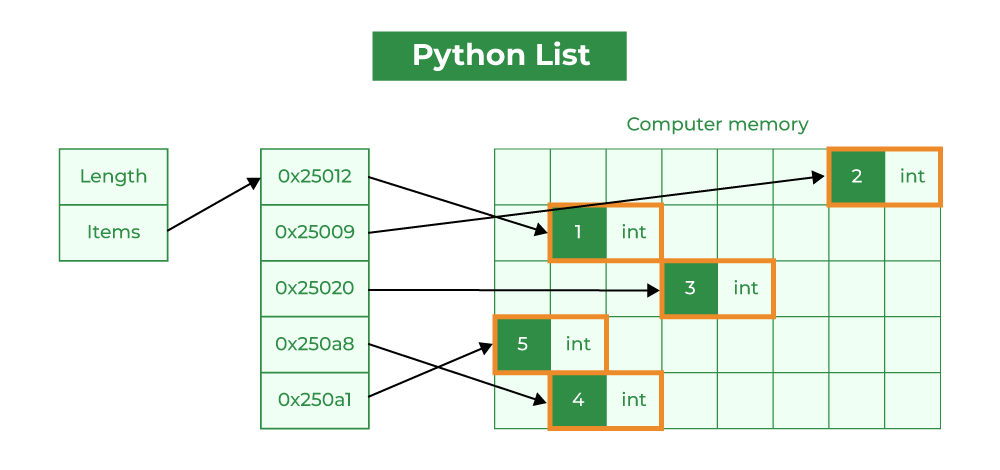
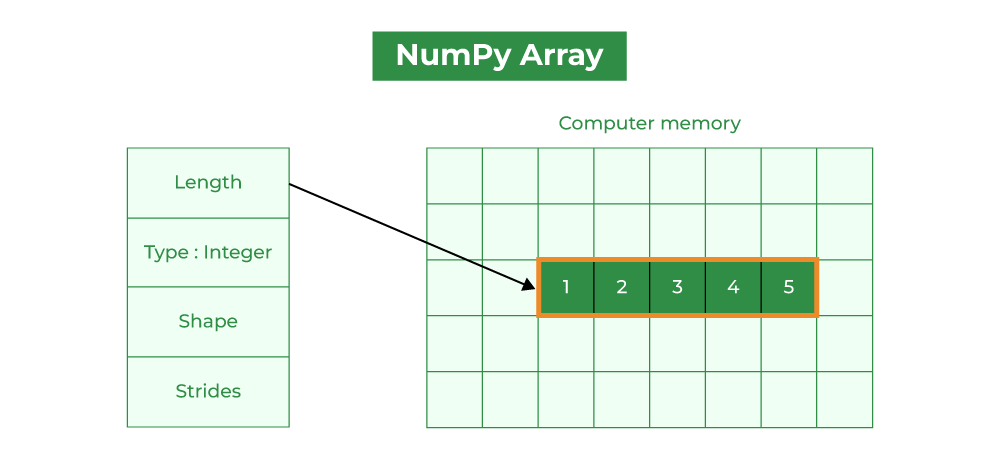\
For the multidimensional arrays the storage depends on the way the data is stored:\
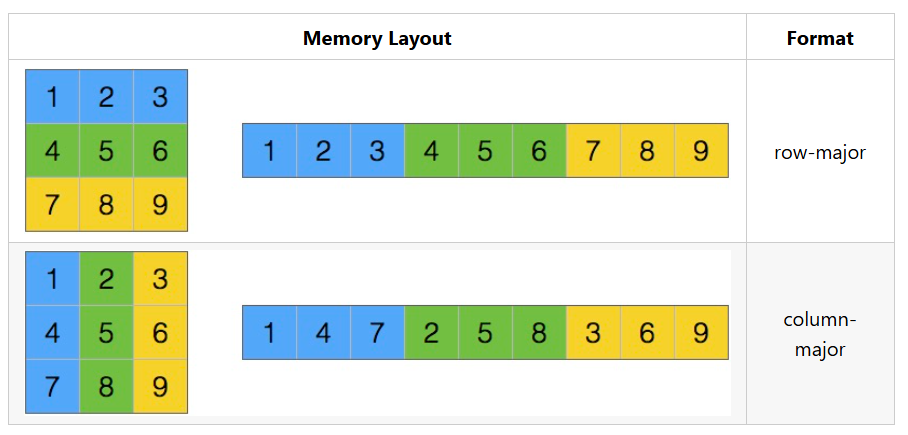\
Typically, for performance reasons, column-major format is used

So how do we create this magical ✨numpy array✨?\
Just convert a list into it via the ```np.array``` function from numpy:

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

#this will print out a numpy array that has values 1,2,3 inside it
print(np.array([1,2,3]))

You also can get a numpy array from any numpy functions, which return data in the form of the numpy array:


In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

#Here you create and print out an array of 5 zeros, for more info check https://numpy.org/devdocs/reference/generated/numpy.zeros.html
#or you can press shift+tab while your cursor is within the function arguments if you're doing this in jupyter (it can sometimes malfunction though)
print(np.zeros(5))

Ok, I created a numpy array, now what?\
Well, what you do now depends on your objective of course, but I'm gonna show you a couple of examples where numpy is really useful:\
For the first task let's imagine that you have 2 arrays of values and you want to multiply them element-wise, which mathematically would look like this:\
$\large \text{Given arrays } [a_0, a_1, ..., a_{n-1}] \text{ and } [b_0, b_1, ..., b_{n-1}] \text{ we want to obtain the array } [c_1, c_2, ..., c_{n-1}] \text{, where }c_i = a_i * b_i \text{ } \forall i \in [0, n-1]$


In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

#enter arbitrary n
n = 10

#vanilla python implementation
arr_a = list(range(n))
arr_b = list(range(n, n*2)) #here I shift the data by 10 for the arrays not to be the same
for idx, a,b in enumerate(zip(arr_a, arr_b)):
    arr_c[idx] = a * b
arr_c = [a*b for a,b in zip(arr_a, arr_b)] #this is called list comprehension, it's just a quick and neat way to create a list from a for loop

#numpy implementation
arr_a_np = np.arange(n) #np.arange is the same as python's range, but better
arr_b_np = np.arange(10, n+10)
arr_c_np = arr_a_np * arr_c_np

The same thing holds true for any python operation:

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

n = 5
#function np.random.rand(n) returns an array of random Uniformly distributed numbers from 0 to 1, basically ~U(0, 1) in statistics
arr_a = np.random.rand(n) 
arr_b = np.arange(1, n+1)
#The script below prints out the values so that you can verify all of this yourselves
print(arr_a + arr_b)
print(arr_a / arr_b)
print(arr_a ** arr_b)

That was just a simple case with 1D data, however you'll often need to work with the tabular data, so you'll need to learn to navigate through the 2D arrays.\
By default in programming you construct a 2D array as a list of lists (in python terms) like this:

In [ ]:
example_arr = [[1,2,3], [4,5,6]]

#### 2D numpy arrays

We can create matrices (and multidimensional tensors) in numpy, but how do we work with them? When you need to refer to some value in the array, you do:

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

sample_2d_arr = np.zeros((2,2)) #2x2 matrix
print(sample_2d_arr[0, 0]) #print the first element, here "," divides the operands for axis 0 and 1

Applying functions to multidimensional arrays:

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

np.random.seed(69) #fix the random seed, it's done for replicability

sample_2d_array = np.random.rand(4,4) #create a 4x5 matrix
print(np.sum(sample_2d_array, axis=0)) #perform the sum operation along the axis 0 (rows of the matrix)

That was nice, but there are of course other things numpy is good for, I'm going to list a couple of useful properties in numpy arrays.\
You'll explore each in detail during your exercises:

1. ```.reshape()``` accepts integers as inputs and reshapes your array, for example:

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

arr = np.arange(10)
print(arr.reshape(5, 2)) #reshapes the array into a 5x2 matrix
print(arr.reshape(1, -1)) #reshapes the array into a matrix where there will be 1 value per row and all others in the column, here it's a 1x10 matrix

2. ```.shape``` gives you the shape of the array, for example:

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library


arr = np.arange(15)
arr = arr.reshape(3, 5)
print(arr.shape) #will print (3,5) as it's the shape we reshaped our array into
print(arr.reshape(3, -1 ,5)) #will print(3, 1, 5), try to guess why

3. ```.astype()``` will assign a certain datatype to the array, you can also do it initially via the ```dtype``` argument:

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

arr = np.arange(12, dtype=int) #here we assing the dtype as integer while creating the array
arr = arr.astype(float) #here we change the dtype to float

4. ```.flatten()``` reshapes your array to a single dimensional array (vector), equivalent to ```.reshape(-1)```

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

arr = np.arange(12, dtype=int).reshape(3, 2, -1)
print(arr.flatten()) #will print an array same to the one created via np.arange(10)

5. ```.copy()``` returns a copy of the array. Ok, this is a very short explanation, but usually when you do something like

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

a = np.arange(10)
b = a

```a``` doesn't actually copy the value of ```b```, in fact they both **point** to the same spot in the memory,\
so modifying ```b``` would modify ```a``` as well, for that not to happen when we don't want it to, there's the ```.copy()``` function

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

arr_1 = np.arange(3)
arr_2 = arr_1
arr_1 += 1
print(arr_1, arr_2) #as you can see, they are the same


arr_3 = np.arange(3)
arr_4 = arr_3.copy()
arr_3 += 5
print(arr_3, arr_4) #as you can see, they are not equal

6. ```.sort()``` sorts the numpy array in the ascending order (if you want a descending order just do ```[::-1]``` after)

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

arr = np.random.rand(5)
arr.sort() #sorts in ascending order
arr = arr[::-1] #descending order

7. ```.sum()```, ```.mean()```, ```.max()```, ```.min()```, ```.var()```, ```.std()``` do what you would expect from functions with such names

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

arr = np.random.rand(10)

print(arr.sum()) #sum of all the elements within the array
print(arr.mean()) #mean of the array
print(arr.max()) #max of the array
print(arr.min()) #min of the array
print(arr.var()) #variance of the array
print(arr.std()) #standard deviation of the array

8. ```.T``` now this isn't really a function, it's a property that's stored (that's why you don't call it via braces), it (kinda) stores the transpose\
   of the array (for the level of your knowledge assume that it just keeps the transposed matrix in some way)\
   What's a transpose of something? This concept comes from linear algebra and is very simple, for a 2D case (for a matrix) a transpose is when an element,\
    for example $\large a_{ij}$ swaps its indices so that $\large a_{ij} \rightarrow a_{ji}$

In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

matrix = np.arange(6).reshape(2, -1)
print(matrix) #initial matrix
print(matrix.T) #transposed version

9. ```.cumsum()``` outputs $\large \sum_{k=0}^{i}x_{k} \forall i \in [0, n-1]$ or in other words the cumulative sum for each element of the array


In [ ]:
#import numpy as np #this line is to be omitted if you already imported the numpy library

arr = np.ones(10)
print(arr.cumsum()) #print the cumulative sum of the array

## Useful numpy functions

Although arrays are **the** backbone of numpy-based calculations, they are not enough. Now you'll get a quick review of some of most frequently used\
functions from numpy and then (you guessed it) you'll do a couple of exercises with them:

1. ```np.linspace()``` creates a list of ```n``` evenly spaced numbers from point ```a``` to point ```b```:

In [ ]:
import numpy as np

#creates an array from 0 to 10 with 5 numbers 
arr = np.linspace(0, 10, 5)
print(arr)

2. ```np.zeros()```, ```np.ones()```, ```np.full()``` - these are the functions that output an array filled with some value that you enter:

In [ ]:
import numpy as np

n = 100
arr_zeros = np.zeros(n) #creates an array of 100 zeros
arr_ones = np.ones(n) #creates an array of 100 ones
#create some random value 
rand_val = np.random.rand()
arr_rand_val = np.full(n, rand_val) #creates an array of 100 instances of rand_val value
print(arr_rand_val)

3. ```np.info()``` provides detailed info about a function or object:

In [ ]:
import numpy as np

print(np.info(np.array))
print(np.info(123))

4. ```np.concatenate()``` concats ```n``` arrays into one along a given axis:

In [ ]:
import numpy as np

#create 3 arrays
arr_1 = np.arange(10)
arr_2 = np.random.rand(12)
arr_3 = np.full(15, np.random.rand())

#concatenate 3 arrays into one along the 0th axis
arr_big = np.concatenate([arr_1, arr_2, arr_3], axis=0)
print(arr_big)

5. ```np.vstack```, ```np.hstack()``` stack arrays vertically and horizontally respectively:

In [ ]:
import numpy as np

n = 10
arr_1 = np.ones(n)
arr_2 = np.zeros(n)

print(np.vstack([arr_1, arr_2]))
print(np.hstack([arr_1, arr_2]))

6. ```np.flip()``` flips the array around the given axis

In [ ]:
import numpy as np

arr = np.arange(10)
print(np.flip(arr))

7. ```np.clip()``` takes two arguments ```min``` and ```max``` and outputs the array, where all elements $\le$ ```min``` = ```min``` and all elements $\ge$ ```max``` = ```max```

In [ ]:
import numpy as np

arr = np.random.rand(10)
print(arr) #before clipping
print(np.clip(arr, .5, .7)) #after clipping

8. ```np.where()``` outputs the indices that satisfy the condition you input

In [ ]:
import numpy as np

n = 5
arr = np.vstack([np.ones(n), np.zeros(n)])
print(np.where(arr == 1)) #prints out the coordinates of the first row of the matrix in the form of 2 rows - coordinates of x and y axis respectively

Time to solve some exercises!

1. Create a 1D NumPy array with values from 0 to 9 using np.arange(). Then create a 2×5 matrix using .reshape(). Print the shape, data type, and flattened version of the matrix

In [ ]:
# your code here

2. Create a fucntion that takes 3 arguments: ```n```, ```op``` and ```seed```. Then inside the function fix the random ```seed``` and\
create 2 random vectors of length ```n``` and perform the operation ```op``` on them. Possible values of ```op``` are ```+```, ```-```, ```*```, ```/``` and ```**```. The program should return an assertion error if ```n```<=0   

In [ ]:
# your code here

3. Demonstrate the difference between assignment and copying. For that write a function that creates a random 1D array ```x```. Assign ```x``` to ```y``` and the copy of ```x``` to ```z```. Modify ```x``` by adding 5 to all elements. Print all arrays to show the difference

In [ ]:
# your code here

4. Write a function that takes as input some 2D array. Return the sum of the columns of the matrix, but you can't apply any mathematical operation (summation, multiplication, subtraction, division, exponentiation in your case) to the matrix columns, you are free to apply any operation to rows though

In [ ]:
# your code here

5. Write a function, which takes as input an n-dimensional array and some condition on the element of the array, it should return the number of elements that satisfies both the input condition and the fact the element is positive 

In [ ]:
# your code here

6. Write the function ```analyze_u_sample``` that takes the following arguments: integer ```seed``` , float ```max_val``` , float ```min_val``` . It then does the following:

    1. Reads from the user some integer number ```n``` to generate the ```n```-long sequence of random numbers that are uniformly distributed from ```min_val``` to ```max_val``` (you are forbidden to use functions that let you explicitly define the range of generated values sampled from the uniform distribution, you **must** transform the values sampled from the initial uniform distribution (values from 0 to 1))
   
    2. Prints out the descriptive statistics to the user (minimum of the sequence, maximum of the sequence, median, mean, standard deviation and variance) and the number of values larger and smaller than the mean. All this is done via f-strings
    
    3. Writes the descriptive statistics, the ```seed``` into some file (the way this data is stored within the file is up to you to choose)

In [ ]:
# your code here